# Token and Latency Analysis for Diffusion LLMs Evaluation

This notebook analyzes token usage and latency across every model under `results/`, while excluding `archive`.

It reports:
- average tokens per metric task
- global average tokens per call
- latency statistics

Each row in the latency CSVs represents one API call.

In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE = Path("/Users/lokovacic/Projects/diffusion-llms-eval")
RESULTS_DIR = BASE / "results"
EXCLUDE_MODELS = {"archive"}

MODEL_DIRS = sorted(
    d for d in RESULTS_DIR.iterdir()
    if d.is_dir() and d.name not in EXCLUDE_MODELS
)

print(f"Found {len(MODEL_DIRS)} models:")
for m in MODEL_DIRS:
    print(f"  {m.name}")

Found 7 models:
  LLaDA2.1-mini
  Qwen3.6-35B-A3B-FP8
  gemma-4-26b-a4b-it
  gemma-4-31b-it
  gemma-4-e2b-it
  gpt-4.1-mini
  qwen35-2b


---
## Helper Functions

In [9]:
def load_all_latency_data(model_dirs: list[Path]) -> pd.DataFrame:
    frames = []
    for model_dir in model_dirs:
        for csv_path in sorted(model_dir.glob("*_latency.csv")):
            df = pd.read_csv(csv_path)
            df = df.copy()
            df["model_dir"] = model_dir.name
            df["source_file"] = csv_path.name
            frames.append(df)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

def p95(series: pd.Series) -> float:
    return series.quantile(0.95)

def round_df(df: pd.DataFrame, digits: int = 3) -> pd.DataFrame:
    return df.map(lambda x: round(x, digits) if isinstance(x, (float, np.floating)) else x)

---
## Load Token and Latency Data

In [10]:
latency_df = load_all_latency_data(MODEL_DIRS)
print(f"Loaded {len(latency_df)} call rows")
display(latency_df.head())
print("\nColumns:")
print(list(latency_df.columns))
print("\nModels:", sorted(latency_df['model'].dropna().unique()))
print("Metric tasks:", sorted(latency_df['metric_name'].dropna().unique()))

Loaded 3006 call rows


,case_id,example_idx,question,metric_name,call_index,prompt,response_model,response,latency_s,prompt_tokens,completion_tokens,total_tokens,cached_tokens,reasoning_tokens,timestamp,model,model_dir,source_file
0,AR1,0,What is LLM-as-a-judge and how does it work?,answer_relevancy,0,Generate a question for the given answer and i...,AnswerRelevanceOutput,question='How does LLM-as-a-judge evaluate AI ...,0.2995,750,38,788,0,0,2026-06-08T20:39:13.992232+00:00,LLaDA2.1-mini,LLaDA2.1-mini,20260608_223913_LLaDA2.1-mini_answer-relevancy...
1,AR2,1,What are the three layers of continual learnin...,answer_relevancy,0,Generate a question for the given answer and i...,AnswerRelevanceOutput,question='What are the three layers of which l...,0.1629,766,38,804,0,0,2026-06-08T20:39:14.981654+00:00,LLaDA2.1-mini,LLaDA2.1-mini,20260608_223913_LLaDA2.1-mini_answer-relevancy...
2,AR3,2,What is agent observability?,answer_relevancy,0,Generate a question for the given answer and i...,AnswerRelevanceOutput,question='What is agent observability in the c...,0.0945,736,37,773,0,0,2026-06-08T20:39:15.547813+00:00,LLaDA2.1-mini,LLaDA2.1-mini,20260608_223913_LLaDA2.1-mini_answer-relevancy...
3,AR4,3,What biases affect LLM-as-a-judge evaluators?,answer_relevancy,0,Generate a question for the given answer and i...,AnswerRelevanceOutput,question='What are the known biases in LLM jud...,0.0873,754,41,795,0,0,2026-06-08T20:39:16.067951+00:00,LLaDA2.1-mini,LLaDA2.1-mini,20260608_223913_LLaDA2.1-mini_answer-relevancy...
4,AR5,4,What is trajectory evaluation and why is it im...,answer_relevancy,0,Generate a question for the given answer and i...,AnswerRelevanceOutput,question='Why is trajectory evaluation importa...,0.0744,752,35,787,0,0,2026-06-08T20:39:16.533156+00:00,LLaDA2.1-mini,LLaDA2.1-mini,20260608_223913_LLaDA2.1-mini_answer-relevancy...



Columns:
['case_id', 'example_idx', 'question', 'metric_name', 'call_index', 'prompt', 'response_model', 'response', 'latency_s', 'prompt_tokens', 'completion_tokens', 'total_tokens', 'cached_tokens', 'reasoning_tokens', 'timestamp', 'model', 'model_dir', 'source_file']

Models: ['LLaDA2.1-mini', 'Qwen3.6-35B-A3B-FP8', 'gemma-4-26b-a4b-it', 'gemma-4-31b-it', 'gemma-4-e2b-it', 'gpt-4.1-mini', 'qwen35-2b']
Metric tasks: ['answer_relevancy', 'context_relevance', 'context_utilization', 'faithfulness_exp1', 'faithfulness_exp2', 'response_groundedness']


---
## Average Tokens Per Metric Task

prompt_tokens                    \
                                                   mean  median       std   
model               metric_name                                             
LLaDA2.1-mini       answer_relevancy            735.100   732.5    16.992   
                    context_relevance          1413.500  1378.0   487.981   
                    context_utilization        1560.545  1646.0   570.562   
                    faithfulness_exp1          1514.425  1268.0  1573.169   
                    faithfulness_exp2          1856.634  1597.0  1017.238   
                    response_groundedness      1376.340  1363.5   441.231   
Qwen3.6-35B-A3B-FP8 answer_relevancy            722.100   719.5    16.941   
                    context_relevance          1306.810  1359.0   327.354   
                    context_utilization        1491.943  1598.0   166.005   
                    faithfulness_exp1          1199.500  1009.0   639.934   
                    faithfulness_exp2          1742.311  1620.0   436.176   
                    response_groundedness      1348.161  1349.0   390.136   
gemma-4-26b-a4b-it  answer_relevancy            756.567   754.0    16.856   
                    context_relevance          1342.500  1394.0   332.667   
                    context_utilization        1519.602  1625.5   171.603   
                    faithfulness_exp1          1217.944  1033.5   633.451   
                    faithfulness_exp2          1777.778  1639.0   444.788   
                    response_groundedness      1369.415  1383.0   394.752   
gemma-4-31b-it      answer_relevancy            756.567   754.0    16.856   
                    context_relevance          1342.500  1394.0   332.667   
                    context_utilization        1519.602  1625.5   171.603   
                    faithfulness_exp1          1224.089  1043.5   642.080   
                    faithfulness_exp2          1777.778  1639.0   444.788   
                    response_groundedness      1369.415  1383.0   394.752   
gemma-4-e2b-it      answer_relevancy            981.867   755.0   690.708   
                    context_relevance          2268.988  1481.0  1865.489   
                    context_utilization        1881.102  1668.5  1031.980   
                    faithfulness_exp1          2281.205  1551.5  2294.252   
                    faithfulness_exp2          2301.556  1824.0  1679.503   
                    response_groundedness      2605.989  1771.0  1817.102   
gpt-4.1-mini        answer_relevancy            673.500   671.0    17.156   
                    context_relevance          1247.476  1300.5   326.176   
                    context_utilization        1388.580  1492.5   164.181   
                    faithfulness_exp1          1130.311   951.0   607.133   
                    faithfulness_exp2          1897.911  1546.0  1148.492   
                    response_groundedness      1281.160  1284.5   388.493   
qwen35-2b           answer_relevancy            724.100   721.5    16.941   
                    context_relevance          1308.810  1361.0   327.354   
                    context_utilization        1493.943  1600.0   166.005   
                    faithfulness_exp1          1179.225   814.0   620.723   
                    faithfulness_exp2          1744.311  1622.0   436.176   
                    response_groundedness      1344.500  1349.5   391.895   

                                                completion_tokens          \
                                          count              mean  median   
model               metric_name                                             
LLaDA2.1-mini       answer_relevancy         30            36.500    37.0   
                    context_relevance        84            13.238    13.0   
                    context_utilization      88            71.693    66.5   
                    faithfulness_exp1        87           432.437   244.0   
                    faithfulness_exp2

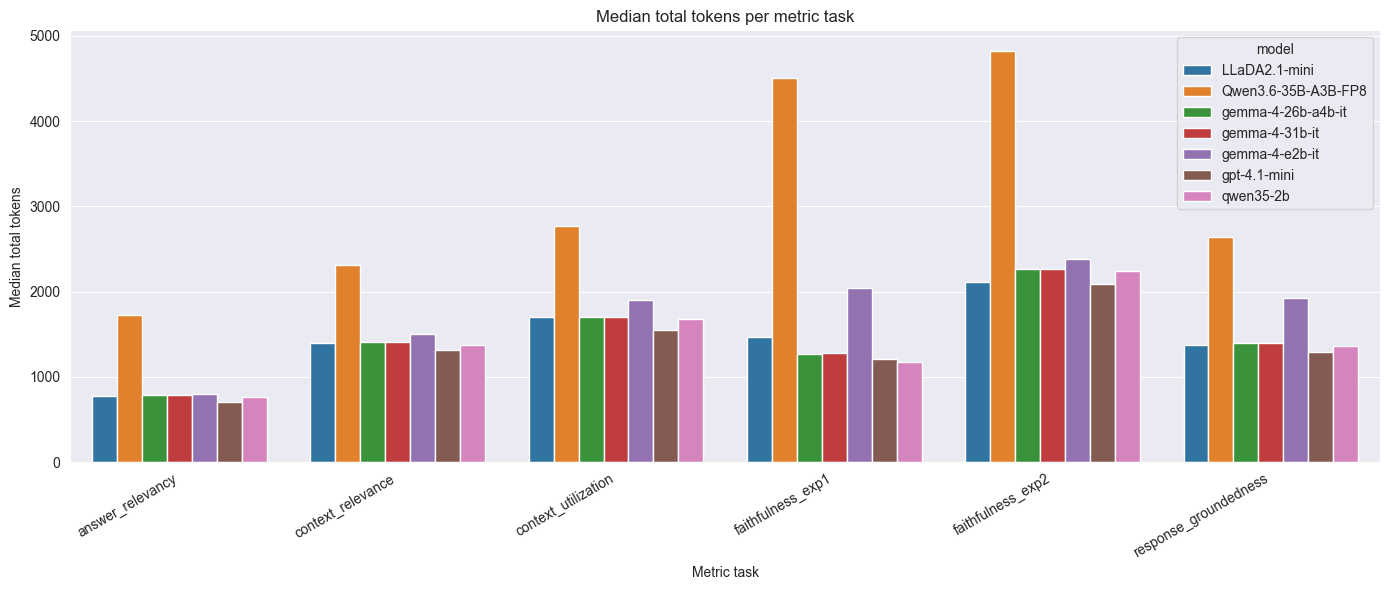

In [11]:
token_cols = [
    'prompt_tokens',
    'completion_tokens',
    'total_tokens',
    'cached_tokens',
    'reasoning_tokens',
]

task_token_summary = (
    latency_df
    .groupby(['model', 'metric_name'])[token_cols]
    .agg(['mean', 'median', 'std', 'count'])
    .sort_index()
)
display(round_df(task_token_summary))

task_token_means = (
    latency_df
    .groupby(['model', 'metric_name'], as_index=False)[token_cols]
    .median(numeric_only=True)
)

plt.figure(figsize=(14, 6))
sns.barplot(data=task_token_means, x='metric_name', y='total_tokens', hue='model')
plt.xticks(rotation=30, ha='right')
plt.title('Median total tokens per metric task')
plt.xlabel('Metric task')
plt.ylabel('Median total tokens')
plt.tight_layout()
plt.show()

---
## Global Average Tokens Per Call

prompt_tokens                         completion_tokens  \
                             mean  median       std count              mean   
model                                                                         
LLaDA2.1-mini            1451.340  1366.0   902.582   424           164.142   
Qwen3.6-35B-A3B-FP8      1335.963  1353.0   464.995   430          1787.477   
gemma-4-26b-a4b-it       1363.183  1380.0   466.382   431           147.413   
gemma-4-31b-it           1364.466  1380.0   468.426   431           151.698   
gemma-4-e2b-it           2179.177  1581.0  1779.076   429           422.909   
gpt-4.1-mini             1287.125  1263.0   585.488   431           147.353   
qwen35-2b                1332.460  1349.5   460.672   430           153.344   

                                            total_tokens                    \
                     median       std count         mean  median       std   
model                                                                        
LLaDA2.1-mini          51.5   311.753   424     1615.481  1449.5  1125.756   
Qwen3.6-35B-A3B-FP8  1332.0  1158.942   430     3123.440  2761.0  1359.086   
gemma-4-26b-a4b-it     54.0   240.361   431     1510.596  1458.0   627.196   
gemma-4-31b-it         50.0   248.210   431     1516.165  1460.0   634.711   
gemma-4-e2b-it        211.0   503.856   429     2602.086  1779.0  2154.896   
gpt-4.1-mini           46.0   259.601   431     1434.478  1335.0   768.514   
qwen35-2b              52.5   249.898   430     1485.805  1435.5   628.523   

                          cached_tokens                        \
                    count          mean median      std count   
model                                                           
LLaDA2.1-mini         424         0.000    0.0    0.000   424   
Qwen3.6-35B-A3B-FP8   430         0.000    0.0    0.000   430   
gemma-4-26b-a4b-it    431         0.000    0.0    0.000   431   
gemma-4-31b-it        431         0.000    0.0    0.000   431   
gemma-4-e2b-it        429         0.000    0.0    0.000   429   
gpt-4.1-mini          431       251.842    0.0  573.748   431   
qwen35-2b             430         0.000    0.0    0.000   430   

                    reasoning_tokens                    
                                mean median  std count  
model                                                   
LLaDA2.1-mini                    0.0    0.0  0.0   424  
Qwen3.6-35B-A3B-FP8              0.0    0.0  0.0   430  
gemma-4-26b-a4b-it               0.0    0.0  0.0   431  
gemma-4-31b-it                   0.0    0.0  0.0   431  
gemma-4-e2b-it                   0.0    0.0  0.0   429  
gpt-4.1-mini                     0.0    0.0  0.0   431  
qwen35-2b                        0.0    0.0  0.0   430

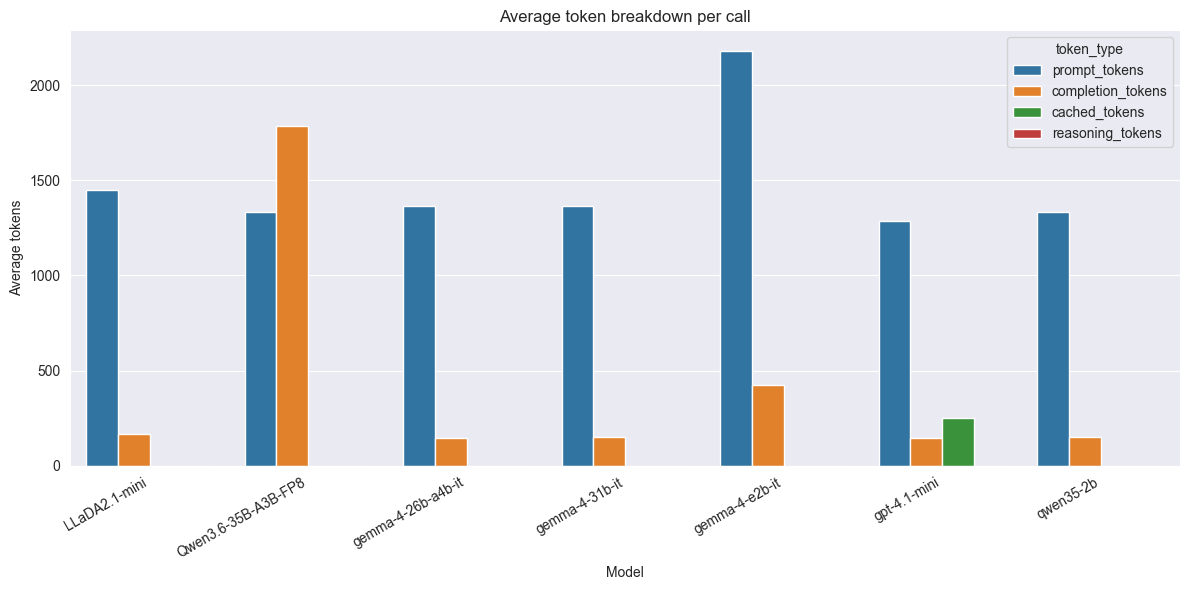

In [12]:
global_token_summary = (
    latency_df
    .groupby('model')[token_cols]
    .agg(['mean', 'median', 'std', 'count'])
    .sort_index()
)
display(round_df(global_token_summary))

global_token_means = (
    latency_df
    .groupby('model', as_index=False)[token_cols]
    .mean(numeric_only=True)
)

plot_df = global_token_means.melt(
    id_vars='model',
    value_vars=['prompt_tokens', 'completion_tokens', 'cached_tokens', 'reasoning_tokens'],
    var_name='token_type',
    value_name='avg_tokens',
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='model', y='avg_tokens', hue='token_type')
plt.xticks(rotation=30, ha='right')
plt.title('Average token breakdown per call')
plt.xlabel('Model')
plt.ylabel('Average tokens')
plt.tight_layout()
plt.show()

---
## Latency Statistics

,mean,median,std,min,max,p95,count
metric_name,,,,,,,
answer_relevancy,1.144,0.386,2.401,0.056,19.791,5.114,210
context_relevance,1.084,0.267,2.172,0.061,16.685,4.813,588
context_utilization,2.024,0.871,2.793,0.086,22.704,6.627,616
faithfulness_exp1,5.962,2.408,7.607,0.073,39.240,21.574,624
faithfulness_exp2,6.179,3.892,6.732,0.114,39.907,19.474,311
response_groundedness,1.453,0.265,2.822,0.061,21.038,7.066,657



### answer_relevancy


,mean,median,std,min,max,p95,count
model,,,,,,,
LLaDA2.1-mini,0.091,0.081,0.046,0.056,0.299,0.156,30
Qwen3.6-35B-A3B-FP8,5.708,4.644,3.946,1.606,19.791,14.285,30
gemma-4-26b-a4b-it,0.319,0.282,0.103,0.231,0.576,0.528,30
gemma-4-31b-it,0.533,0.484,0.138,0.394,0.883,0.807,30
gemma-4-e2b-it,0.469,0.207,0.679,0.163,2.367,2.219,30
gpt-4.1-mini,0.565,0.559,0.074,0.458,0.784,0.700,30
qwen35-2b,0.322,0.178,0.424,0.147,1.949,1.211,30



### context_relevance


,mean,median,std,min,max,p95,count
model,,,,,,,
LLaDA2.1-mini,0.167,0.166,0.060,0.061,0.341,0.267,84
Qwen3.6-35B-A3B-FP8,5.020,4.443,2.954,0.897,16.685,11.312,84
gemma-4-26b-a4b-it,0.203,0.187,0.055,0.150,0.393,0.337,84
gemma-4-31b-it,0.392,0.338,0.135,0.231,0.703,0.621,84
gemma-4-e2b-it,1.012,0.155,1.855,0.122,11.985,4.197,84
gpt-4.1-mini,0.601,0.421,1.521,0.357,14.363,0.555,84
qwen35-2b,0.191,0.196,0.073,0.115,0.378,0.335,84


...

,mean,median,std,min,max,p95,count
model,,,,,,,
LLaDA2.1-mini,0.657,0.451,1.045,0.073,9.417,1.497,87
Qwen3.6-35B-A3B-FP8,16.102,15.041,8.487,5.032,37.412,33.511,90
gemma-4-26b-a4b-it,4.452,1.925,5.023,0.276,20.579,15.669,90
gemma-4-31b-it,9.002,5.958,8.673,0.462,38.847,26.624,90
gemma-4-e2b-it,5.931,3.534,6.738,0.203,39.240,17.133,88
gpt-4.1-mini,2.465,1.512,3.147,0.504,22.100,5.215,90
qwen35-2b,2.915,1.778,3.542,0.325,17.101,10.448,89



### faithfulness_exp2


,mean,median,std,min,max,p95,count
model,,,,,,,
LLaDA2.1-mini,0.555,0.489,0.428,0.114,2.402,1.049,41
Qwen3.6-35B-A3B-FP8,15.264,13.800,8.106,5.153,39.907,29.721,45
gemma-4-26b-a4b-it,6.580,4.569,6.364,0.793,36.260,15.704,45
gemma-4-31b-it,6.836,5.391,4.803,1.534,21.268,18.168,45
gemma-4-e2b-it,6.154,4.197,5.886,0.741,23.888,19.534,45
gpt-4.1-mini,3.250,2.628,2.614,0.873,11.874,8.483,45
qwen35-2b,4.116,1.997,4.563,0.420,22.291,12.254,45



### response_groundedness


,mean,median,std,min,max,p95,count
model,,,,,,,
LLaDA2.1-mini,0.164,0.164,0.063,0.061,0.295,0.275,94
Qwen3.6-35B-A3B-FP8,6.844,5.873,3.361,2.999,21.038,15.809,93
gemma-4-26b-a4b-it,0.180,0.181,0.016,0.152,0.233,0.207,94
gemma-4-31b-it,0.398,0.347,0.166,0.227,0.813,0.738,94
gemma-4-e2b-it,1.852,0.163,2.622,0.123,17.138,5.650,94
gpt-4.1-mini,0.581,0.417,1.441,0.359,14.393,0.550,94
qwen35-2b,0.210,0.208,0.076,0.115,0.393,0.329,94


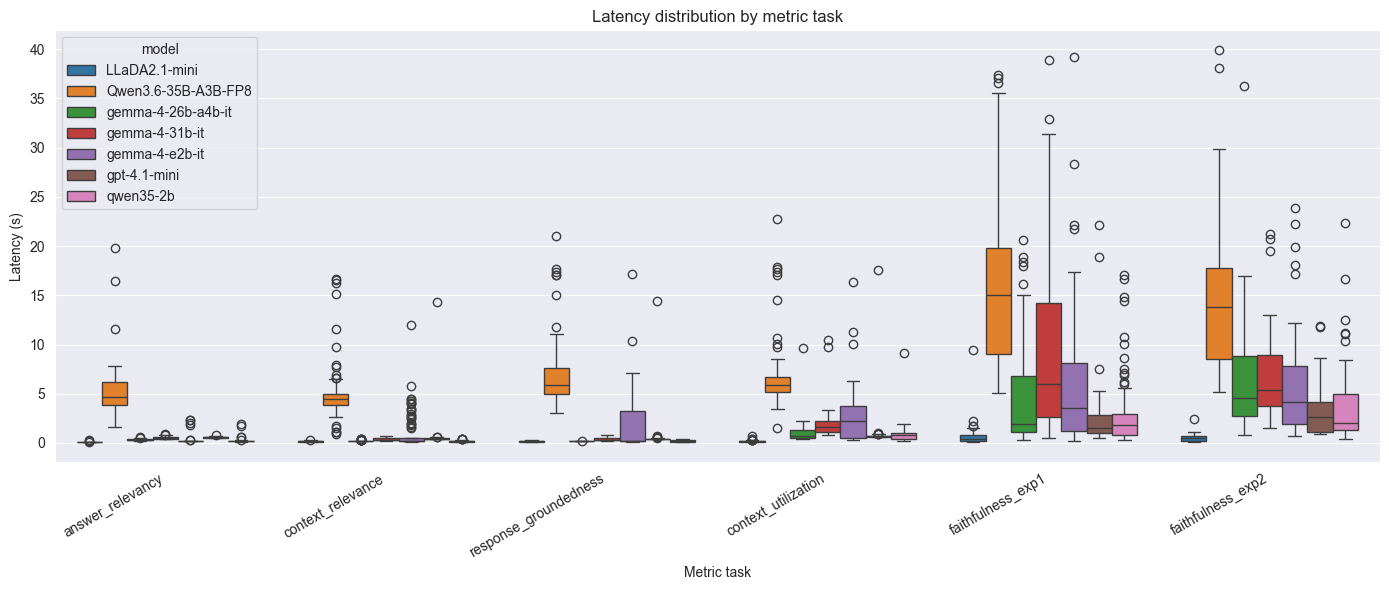

In [13]:
latency_overall_by_metric = (
    latency_df
    .groupby('metric_name')['latency_s']
    .agg(['mean', 'median', 'std', 'min', 'max', p95, 'count'])
    .rename(columns={'p95': 'p95'})
    .sort_index()
)
display(round_df(latency_overall_by_metric))

for metric_name in sorted(latency_df['metric_name'].dropna().unique()):
    metric_df = latency_df[latency_df['metric_name'] == metric_name]
    metric_latency_summary = (
        metric_df
        .groupby('model')['latency_s']
        .agg(['mean', 'median', 'std', 'min', 'max', p95, 'count'])
        .rename(columns={'p95': 'p95'})
        .sort_index()
    )
    print(f"\n### {metric_name}")
    display(round_df(metric_latency_summary))

plt.figure(figsize=(14, 6))
sns.boxplot(data=latency_df, x='metric_name', y='latency_s', hue='model')
plt.xticks(rotation=30, ha='right')
plt.title('Latency distribution by metric task')
plt.xlabel('Metric task')
plt.ylabel('Latency (s)')
plt.tight_layout()
plt.show()


---
## Optional Export

In [14]:
task_token_summary.to_csv(RESULTS_DIR / 'token_latency_task_summary.csv')
global_token_summary.to_csv(RESULTS_DIR / 'token_latency_global_summary.csv')
latency_summary.to_csv(RESULTS_DIR / 'token_latency_latency_summary.csv')
print('Saved summary CSVs to results/')

Saved summary CSVs to results/
